# Ordering Planet Imagery


This tutorial uses [Planet](https://www.planet.com)'s Data and Orders API using the official [Python client](https://github.com/planetlabs/planet-client-python), the `planet` module. We will search for imagery while filtering for clouds based on a specific AOI.

## Requirements

This tutorial assumes familiarity with the [Python](https://python.org) programming language throughout. Python modules used in this tutorial are:
* [IPython](https://ipython.org/) and [Jupyter](https://jupyter.org/)
* [planet](https://github.com/planetlabs/planet-client-python)
* [geojsonio](https://pypi.python.org/pypi/geojsonio)
* [rasterio](https://rasterio.readthedocs.io/en/latest/index.html)
* [shapely](https://shapely.readthedocs.io/en/stable/index.html)
* [asyncio](https://docs.python.org/3/library/asyncio.html)

You should also have an account on the Planet Platform and retrieve your API key from your [account page](https://www.planet.com/account/).

## Useful links 
* [Planet Client V2 Documentation](https://github.com/planetlabs/planet-client-python)
* [Planet Data API reference](https://developers.planet.com/docs/apis/data/)

## Set up

In order to interact with the Planet API using the client, we need to import the necessary packages & define helper functions.

In [1]:
#general packages
import os
import os
import pytz

import json
import pathlib
from datetime import datetime
from collections import Counter
import datetime
import pyproj
from shapely.ops import transform
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
import pandas as pd
from datetime import datetime
from dateutil import parser
from collections import defaultdict
import requests
from shapely.geometry import shape, mapping
from shapely.ops import unary_union
from dotenv import load_dotenv

load_dotenv()


# We will also create a small helper function to print out JSON with proper indentation.
def indent(data):
    print(json.dumps(data, indent=2))

We next need to create a `client` object registered with our API key. The API key will be automatically read from the `PL_API_KEY` environment variable if it exists. You can also authenticate via the CLI using [`auth init`](https://planet-sdk-for-python-v2.readthedocs.io/en/latest/cli/cli-reference/?h=auth#auth:~:text=message%20and%20exit.-,auth,-%C2%B6), this will store your API key as an environment variable.

In [2]:
# if your Planet API Key is not set as an environment variable, you can paste it below
API_KEY = os.getenv('PL_API_KEY', '')

    # construct auth tuple for use in the requests library
BASIC_AUTH = (API_KEY, '')

## Searching for available imagery

We can search for items that are interesting by using the `quick_search` member function. Searches, however, always require a proper request that includes a filter that selects the specific items to return as seach results.

Let's also read in a GeoJSON geometry into a variable so we can use it during testing. The geometry can only have one polygon to work with the data API

In [3]:
with open("user_inputs/Pacific_Rim_National_Park.geojson") as f:
    geom_all = json.loads(f.read())['features'][0]['geometry']  

# Setup Planet Data API base URL
URL = "https://api.planet.com/data/v1/quick-search"

# Setup the session
session = requests.Session()

# Authenticate
session.auth = (API_KEY, "")

### Filters

The possible filters include `and_filter`, `date_range_filter`, `range_filter` and so on, mirroring the options supported by the Planet API. Additional filters are described [here](https://planet-sdk-for-python-v2.readthedocs.io/en/latest/python/sdk-guide/#filter:~:text=(main())-,Filter,-%C2%B6).

In [4]:
# Define the filters we'll use to find our data
item_types = ["PSScene"]
#Date range filter
start_date = "2009-01-01T00:00:00.000Z"
end_date = "2025-12-31T00:00:00.000Z"

#Cloud cover filter
clear_percent =  10

#String filter for available asset
asset_type = "ortho_analytic_4b"

# Setup the request
request = {
    "item_types": item_types,
    "filter": {
        'type': 'AndFilter',
        'config': [
            {
                'type': 'GeometryFilter',
                'field_name': 'geometry',
                'config': geom_all
            },
            {
                'type': 'RangeFilter',
                'field_name': 'clear_percent',
                'config': {'gt': clear_percent}
            },
            {
                'type': 'AssetFilter',
                'config': [asset_type]
            },
            {
                'type': 'DateRangeFilter',
                'field_name': 'acquired',
                'config': {'gte': start_date, 'lte': end_date}
            }
        ]
    }
}
 

Now let's send the request, returning the first 250 results

In [5]:
# Send the POST request to the API quick search endpoint
res = session.post(URL, json=request)

# Assign the response to a variable
results = res.json()["features"]



To get the rest of the results you must paginate using the `_next` link. Printing out the number of available images within your AOI and TOI with greater then 60% clear pixels

In [6]:
next_url = res.json()['_links']['_next']

while next_url:
    next_features = session.get(next_url)
    results.extend(next_features.json()['features'])
    try:
        next_url = next_features.json()['_links']['_next']
    except:
        next_url = None

print(f"Total results: {len(results)}")



Total results: 5255


## AOI coverage filtering

First stage is to group all of the imagery by strip

In [7]:
grouped = defaultdict(list)

for item in results:
    acquired_time = item["properties"]["acquired"]
    date_str = acquired_time.split("T")[0]
    date_strip = date_str+"_"+item["properties"]["strip_id"]
    grouped[date_strip].append(item)

print("Strips of imagery:", len(grouped.keys()))


Strips of imagery: 2683


Next compare the daily image coverage with your AOI, filtering out any day with lass coverage then the desired threshold

In [8]:
def calculate_area(geom):
    # Reproject to a meter-based coordinate system (Web Mercator here) Initially used 3857
    projected = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:6933", always_xy=True).transform
    aoi_geom = transform(projected, shape(geom))
    geom_area = aoi_geom.area / 1e6  # Convert m^2 to km^2
    return geom_area

In [9]:
aoi_coverage_threshold = 0.99

# Convert the GeoJSON geometry to a shapely geometry object
aoi_geom = shape(geom_all)
geom_area = calculate_area(geom_all)
print(f"Geom Area: {geom_area:.2f} km^2")

valid_days = {}
merged_features = []

for day, items in grouped.items():
    shapely_geoms = []
    for meta in items:
        if 'geometry' in meta:
            shapely_geoms.append(shape(meta['geometry']))
    if not shapely_geoms:
        print(f"No valid geometries for {day}")
        continue

    merged_geom = unary_union(shapely_geoms)
    intersection_area = calculate_area(merged_geom.intersection(aoi_geom))
    overlap_ratio = float(intersection_area) / float(geom_area)

    if overlap_ratio >= aoi_coverage_threshold:
        valid_days[day] = items
        merged_features.append({
            "type": "Feature",
            "properties": {
                "day": day,
                "overlap_ratio": overlap_ratio
            },
            "geometry": mapping(merged_geom.intersection(aoi_geom))
        })

print(f"Strips passing {aoi_coverage_threshold*100}% overlap criterion:", len(valid_days.keys()))

merged_collection = {
    "type": "FeatureCollection",
    "features": merged_features
}

with open("merged_geoms.geojson", "w") as f:
    json.dump(merged_collection, f)

Geom Area: 109.96 km^2
Strips passing 99.0% overlap criterion: 172


Aggregate all of the days together into a set of Image IDs

In [10]:
valid_IDs = {}
for day, items in valid_days.items():
    for item in items:
        valid_IDs[item['id']] = item

print("Number of valid IDs: ", len(valid_IDs))

Number of valid IDs:  459


## AOI based cloud filtering
The data api searches based on scene wide cloud statistics which means that a scene that is occasionally 60% clear might have clouds covering most of your AOI. We can do AOI level cloud filtering but it takes a bit longer so its good to filter down first with a normal data API call.

In [11]:
def create_cloud_filter_request(item_id):
    url = f"https://api.planet.com/data/v1/item-types/PSScene/items/{item_id}/coverage"
    headers = {
        "Content-Type": "application/json"
    }
    data = {
        "geometry": geom_all
    }

    return requests.post(url, headers=headers, json=data, auth=(API_KEY, ""))
    

In [12]:
item_cloud = {}

Itterate over all of the images found using the data API, making a request for AOI based cloud cover.

Could cover requests take about 10 min to be processed on Planets side. The first time running will place the request and once activated the request will return a cloud cover value. Placing the request for 300 images takes approximately 10 min. 

Problematic files that do not get a 200 code will be stored in the problematic dictionary and can be delt with on a case by case basis.

Rerun this code again until there are no more files in the activated stage

In [13]:
# For 500 images this took 20 minutes
i = 1
total_files = len(valid_IDs)
problematic = {}
for item_id in list(valid_IDs.keys()):
    item_id 
        
    print(f"Processing file {i}/{total_files}", end="\r") 
    if item_id not in item_cloud:
        request = create_cloud_filter_request(item_id)
        if request.status_code == 200:
            item_cloud[item_id] = request
        else:
            problematic[item_id] = request

    elif item_cloud[item_id].status_code == 200:
        if item_cloud[item_id].json()["status"] == 'activating':
            request = create_cloud_filter_request(item_id)
            if request.status_code == 200:
                item_cloud[item_id] = request
            else:
                problematic[item_id] = item_cloud
    elif item_cloud[item_id].status_code == 500:
        request = create_cloud_filter_request(item_id)
        if request.status_code == 200:
            item_cloud[item_id] = request
        else:
            problematic[item_id] = request

    i += 1

for item in item_cloud:
    if item_cloud[item].status_code != 200:
        print(item_cloud[item].status_code)

count_complete = sum(resp.json()['status'] == 'complete' for resp in item_cloud.values())
print(f"\nItems completed: {count_complete}")
count_complete = sum(resp.json()['status'] == 'activating' for resp in item_cloud.values())
print(f"Incomplete Items: {count_complete}")
print(f"Items with errors: {len(problematic)}")

Processing file 459/459
Items completed: 455
Incomplete Items: 0
Items with errors: 4


## Filter out the imagery based on the AOI level clear percent

In [14]:
order_imagery = {}
cloudy_imagery = {}
clear_percent_threshold = 90


for item in list(item_cloud.keys()):
    if item_cloud[item].status_code == 200:
        if item_cloud[item].json()["status"] == 'complete':
            if item_cloud[item].json()['clear_percent'] > clear_percent_threshold:
                order_imagery[item] = item_cloud[item].json()['clear_percent']
            else:
                cloudy_imagery[item] = item_cloud[item].json()['clear_percent']

print("Number of suitible images: " + str(len(order_imagery)))
print("Number of images exceding cloud cover: " + str(len(cloudy_imagery)))

Number of suitible images: 239
Number of images exceding cloud cover: 216


In [15]:
order_imagery

{'20241208_193143_24_24d5': 100,
 '20241114_193848_40_2521': 91,
 '20241010_184537_83_24b5': 97,
 '20241010_184535_73_24b5': 96,
 '20240929_193324_28_2515': 100,
 '20240929_193326_68_2515': 98,
 '20231208_183030_08_24cf': 96,
 '20231208_183025_72_24cf': 100,
 '20231208_183027_90_24cf': 96,
 '20231125_183226_29_24ab': 95,
 '20231125_183224_13_24ab': 97,
 '20231125_183221_97_24ab': 100,
 '20240613_183624_46_2417': 96,
 '20240613_183622_35_2417': 99,
 '20240711_185454_13_2440': 97,
 '20240711_192843_84_24ed': 100,
 '20240706_192653_96_24ed': 99,
 '20240706_192649_54_24ed': 100,
 '20240706_192651_75_24ed': 99,
 '20240702_183856_47_24a7': 98,
 '20240702_183858_59_24a7': 99,
 '20240517_193026_43_24e8': 94,
 '20240517_193024_13_24e8': 93,
 '20240517_193021_84_24e8': 96,
 '20240405_183855_60_24af': 99,
 '20240405_183857_76_24af': 98,
 '20240207_183304_90_2423': 92,
 '20240207_183300_96_2423': 100,
 '20240111_183807_46_2439': 93,
 '20231029_182515_93_2459': 99,
 '20231029_182518_04_2459': 99,
 

# Visualize image distribution

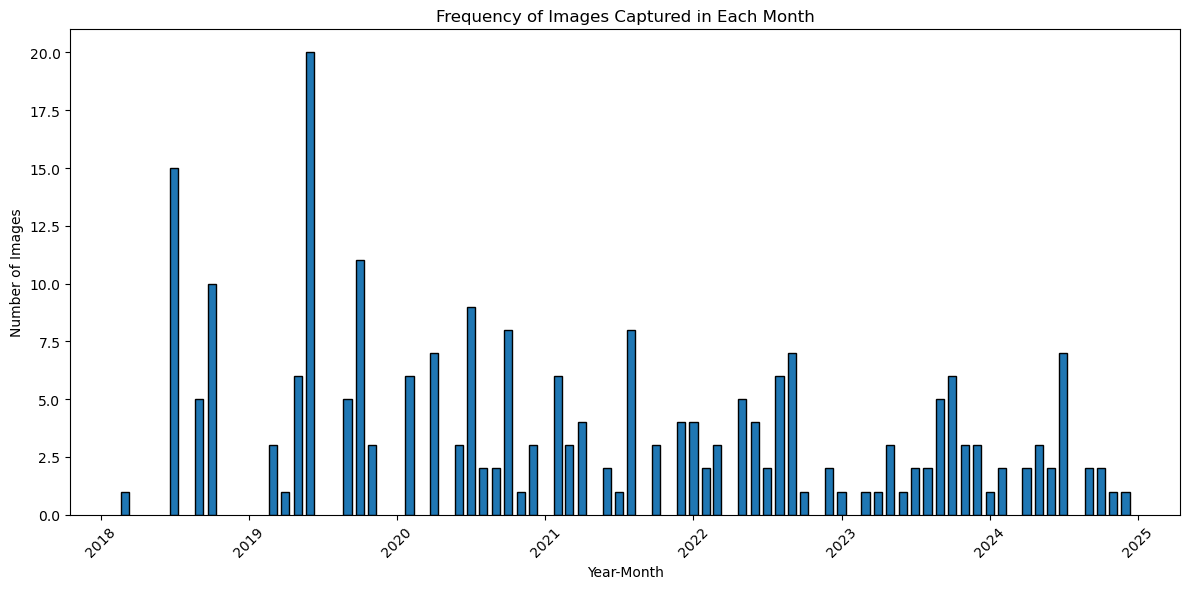

In [16]:
# Extract year and month from image IDs
year_months = [img_id[:6] for img_id in order_imagery]

# Count the frequency of each year-month
year_month_counts = Counter(year_months)

# Convert year-month strings to datetime objects for plotting
year_month_objects = [datetime.strptime(year_month, '%Y%m') for year_month in year_month_counts.keys()]
counts = list(year_month_counts.values())

# Create a histogram
plt.figure(figsize=(12, 6))
plt.bar(year_month_objects, counts, width=20, edgecolor='black')
plt.xlabel('Year-Month')
plt.ylabel('Number of Images')
plt.title('Frequency of Images Captured in Each Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Extract the clearest dates every month

New function that selects the strip that covers the most of the AOI by day

In [17]:
def select_strip(ids):
    grouped_by_strip = defaultdict()
    # Group the items by strip_id
    for item_id in ids:
        strip = valid_IDs[item_id]["properties"]["satellite_id"]
        if strip not in grouped_by_strip:
            grouped_by_strip[strip] = []
        grouped_by_strip[strip].append(valid_IDs[item_id])

    largest_area = 0
    best_strip = None
    for strip, geoms in grouped_by_strip.items():
        geometry_list = []
        for geom in geoms:
            geometry_list.append(shape(geom['geometry']))
        merged_geom = unary_union(geometry_list)
        area = merged_geom.area 
        if area > largest_area:
            largest_area = area
            best_strip = strip
    strip_ids = []
    for item in grouped_by_strip[best_strip]:
        strip_ids.append(item['id'])

    # Return all item IDs belonging to that largest strip
    return strip_ids

In [18]:
num_day_per_month = 4

# 1) Group images by year-month-day
monthly_groups = defaultdict(lambda: defaultdict(list))
for image_id, cloud_cover in order_imagery.items():
    # First 8 characters = YYYYMMDD
    date_str = image_id[:8]
    dt = datetime.strptime(date_str, "%Y%m%d")  # parse into a datetime
    year_month = dt.strftime("%Y-%m")           # e.g. "2024-01"
    day = dt.strftime("%d")
    
    monthly_groups[year_month][day].append((image_id, cloud_cover))


# 2) For each year-month, sort by cloud cover and pick up to 3
selected_images = {}
for ym, days in monthly_groups.items():
    # Sort by ascending cloud cover
    for day, images in days.items():
        average_cloud = sum(img[1] for img in images) / len(images)
        monthly_groups[ym][day] = [images,average_cloud]
# 3) Select up to 3 days with the clearest cover for each year-month
for ym, days in monthly_groups.items():
    # Sort days by average cloud cover
    sorted_days = sorted(days.items(), key=lambda x: x[1][1], reverse=True)
    # Select up to 3 days with the clearest cover
    for i in range(num_day_per_month):
        if i < len(sorted_days):
            date = ym + "-" + sorted_days[i][0]
            ids = []
            for id in sorted_days[i][1][0]:
                ids.append(id[0])
            ids = select_strip(ids)

            selected_images[date] = ids
            print(date)

    # for day, (images, avg_cloud) in sorted_days[:3]:
    #     selected_images.append()


print("Number of days selected: " + str(len(selected_images)))

2024-12-08
2024-11-14
2024-10-10
2024-09-29
2023-12-08
2023-11-25
2024-06-13
2024-07-06
2024-07-11
2024-07-02
2024-05-17
2024-04-05
2024-02-07
2024-01-11
2023-10-25
2023-10-29
2023-09-30
2023-09-28
2021-12-31
2021-02-17
2021-02-05
2020-12-28
2020-12-01
2020-11-15
2020-10-21
2020-10-12
2023-08-18
2020-06-14
2020-07-30
2020-07-24
2020-04-09
2020-04-10
2020-04-27
2020-02-10
2020-02-08
2020-02-01
2019-06-11
2019-06-20
2019-06-19
2019-06-25
2019-04-26
2019-05-10
2019-05-22
2023-07-03
2023-06-23
2023-05-09
2023-04-27
2023-03-13
2023-01-01
2021-06-27
2022-12-01
2021-08-11
2021-08-12
2021-08-10
2021-10-30
2021-10-23
2022-10-28
2022-09-25
2022-09-10
2022-09-06
2022-08-18
2022-08-16
2022-08-06
2022-08-11
2022-07-11
2022-06-23
2022-06-07
2022-06-14
2022-05-20
2022-05-19
2022-03-06
2022-03-19
2022-02-16
2022-01-07
2022-01-25
2021-07-27
2021-04-05
2021-04-10
2021-03-29
2020-08-12
2019-11-01
2019-10-26
2019-10-29
2019-09-18
2019-03-02
2018-10-13
2018-10-21
2018-09-06
2018-07-16
2018-07-22
2018-07-11

## Select the images with the most similar tides

In [19]:
tide_csv = "tides/Pacific_Rim_tides.csv"

# 1) Load tide data
tide_df = pd.read_csv(tide_csv)
# Ensure columns exist
required_cols = {"dates", "tide"}

# 2) Parse datetime from CSV's date & time
tide_df["datetime"] = tide_df["dates"].apply(parser.parse)

tide_df.set_index("datetime", inplace=True)

# Create a dictionary {datetime: tide_height} for fast lookup
tide_dict = tide_df["tide"].to_dict()



For 300 images this step will take about 10 min

In [20]:
from bisect import bisect_left

target_tide=0
min_tide=-130
max_images=4


image_ids = list(order_imagery.keys())

tide_times = sorted(tide_dict.keys())

def find_closest_time(target_dt, sorted_times):
    pos = bisect_left(sorted_times, target_dt)
    candidates = []

    if pos > 0:
        candidates.append(sorted_times[pos - 1])
    if pos < len(sorted_times):
        candidates.append(sorted_times[pos])

    return min(candidates, key=lambda t: abs(t - target_dt))

# 3) For each image ID, parse date/time, look up tide, store by month
monthly_groups = defaultdict(list)
i = 1
for image_id in image_ids:

    # Extract date/time from image ID
    # first 8 chars: YYYYMMDD, next 6 chars: HHMMSS
    date_str = image_id[:8]
    time_str = image_id[9:15]
    
    try:
        dt = datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")
        dt = dt.replace(tzinfo=pytz.UTC)  # Make datetime object timezone-aware

    except ValueError:
        # If the image ID doesn't match the expected format, skip or handle differently
        print("Wrong Format")
        continue
    if dt > datetime(2025, 1, 1, tzinfo=pytz.UTC):
        continue
    closest_time = find_closest_time(dt, tide_times)
    tide_height = tide_dict[closest_time]

    diff = abs(tide_height - target_tide)
    if tide_height >= min_tide:
        # Group by month (YYYY-MM)
        print(f" -{i}/{str(len(image_ids))}- {image_id}: time={dt}, closest time={closest_time}, tide={tide_height}, difference={diff}")
        year_month = dt.strftime("%Y-%m")
        monthly_groups[year_month].append((image_id, tide_height, diff))
    else:
        print(f" -{i}/{str(len(image_ids))}- {image_id}:  tide={tide_height} and is too low")
    i += 1

 -1/239- 20241208_193143_24_24d5: time=2024-12-08 19:31:43+00:00, closest time=2024-12-08 19:30:00+00:00, tide=-0.4965092220233062, difference=0.4965092220233062
 -2/239- 20241114_193848_40_2521: time=2024-11-14 19:38:48+00:00, closest time=2024-11-14 19:45:00+00:00, tide=1.3064354267524376, difference=1.3064354267524376
 -3/239- 20241010_184537_83_24b5: time=2024-10-10 18:45:37+00:00, closest time=2024-10-10 18:45:00+00:00, tide=-0.0361052153205251, difference=0.0361052153205251
 -4/239- 20241010_184535_73_24b5: time=2024-10-10 18:45:35+00:00, closest time=2024-10-10 18:45:00+00:00, tide=-0.0361052153205251, difference=0.0361052153205251
 -5/239- 20240929_193324_28_2515: time=2024-09-29 19:33:24+00:00, closest time=2024-09-29 19:30:00+00:00, tide=0.8458984460660054, difference=0.8458984460660054
 -6/239- 20240929_193326_68_2515: time=2024-09-29 19:33:26+00:00, closest time=2024-09-29 19:30:00+00:00, tide=0.8458984460660054, difference=0.8458984460660054
 -7/239- 20231208_183030_08_24c

In [21]:
monthly_groups['2024-11']

[('20241114_193848_40_2521', 1.3064354267524376, 1.3064354267524376)]

In [22]:
# 4) Select up to `max_images` images with the smallest difference per month
selected_images = {}
for ym, entries in monthly_groups.items():
    # Sort by difference from target
    entries_sorted = sorted(entries, key=lambda x: x[2])  # x[2] is diff
    # print(entries_sorted)
    # # Take first N
    # top_n = entries_sorted[:max_images]
    days = {}
    for image in entries_sorted:
        image_date = image[0][:8]
        if image_date not in days:
            days[image_date] = [image[0]]
        else:
            days[image_date].append(image[0])
    for day, ids in days.items():
        ids = select_strip(ids)
        if ym not in selected_images:
            selected_images[ym] = ids
        else:
            selected_images[ym].extend(ids)

print(f"Selected images closest to {target_tide}m tide (max 3 per month):")
for month in selected_images:
    
    print(f" - {month}: images={selected_images[month]}")


Selected images closest to 0m tide (max 3 per month):
 - 2024-12: images=['20241208_193143_24_24d5']
 - 2024-11: images=['20241114_193848_40_2521']
 - 2024-10: images=['20241010_184537_83_24b5', '20241010_184535_73_24b5']
 - 2024-09: images=['20240929_193324_28_2515', '20240929_193326_68_2515']
 - 2023-12: images=['20231208_183030_08_24cf', '20231208_183025_72_24cf', '20231208_183027_90_24cf']
 - 2023-11: images=['20231125_183226_29_24ab', '20231125_183224_13_24ab', '20231125_183221_97_24ab']
 - 2024-06: images=['20240613_183624_46_2417', '20240613_183622_35_2417']
 - 2024-07: images=['20240706_192653_96_24ed', '20240706_192649_54_24ed', '20240706_192651_75_24ed', '20240702_183856_47_24a7', '20240702_183858_59_24a7', '20240711_192843_84_24ed']
 - 2024-05: images=['20240517_193026_43_24e8', '20240517_193024_13_24e8', '20240517_193021_84_24e8']
 - 2024-04: images=['20240405_183855_60_24af', '20240405_183857_76_24af']
 - 2024-02: images=['20240207_183304_90_2423', '20240207_183300_96_2423

## Ordering

Create a function to place Planet orders given a json request and the function that creates the request given an array of IDs and an order name

In [23]:
# set content type to json
headers = {'content-type': 'application/json'}
orders_url = 'https://api.planet.com/compute/ops/orders/v2' 


def place_order(request, auth):
    response = requests.post(orders_url, data=json.dumps(request), auth=auth, headers=headers)
    print(response)
    order_id = response.json()['id']
    print(order_id) 
    return order_id


def assemble_order(item_ids, name):
    request = {  
        "name":name,
        "products":[
            {  
                "item_ids":item_ids,
                "item_type":"PSScene",
                "product_bundle":"analytic_udm2"
            }
        ],
        "tools":[
            {  
                "clip":{  
                    "aoi":geom_all
                }
            },
            {  
                "composite":{  
                    "group_by":"strip_id"
                }
            }
        ]
    }
    return request



Now we can order all the scenes at once, decide between the tide based selection or the cloud based selection

In [24]:
def calculate_order_quota(ids):
    strips = {}
    for item_id in ids:
        strip = valid_IDs[item_id]["properties"]["strip_id"]
        if strip not in strips:
            strips[strip] = []
        strips[strip].append(item_id)
    strip_areas = 0
    for s, item_ids in strips.items():
        geometry_list = []
        for item_id in item_ids:
            geometry_list.append(shape(valid_IDs[item_id]["geometry"]))
        merged_geom = unary_union(geometry_list).intersection(shape(geom_all))
        
        strip_areas += float(calculate_area(merged_geom))

    return strip_areas

This should calculate order quota ahead of placing orders

In [25]:
order_requests = []
total_quota = 0
# Iterate over each chunk and place the order
for date, ids in selected_images.items():
    order_name = f"Pacific_Rim_1_{date}"
    order_quota = calculate_order_quota(ids)
    #Planet requires a minimum order size of 100 km^2
    if order_quota < (geom_area / 2):
        print(f"Order for {order_name}: {order_quota:.3f}, not adding as its less than half the area.")
    elif order_quota < 100:
        print(f"Order for {order_name}: {order_quota:.3f}, adjusted to 100 km^2")
        order_quota = 100
        total_quota += order_quota
        order_requests.append(assemble_order(ids, order_name))
    else:
        print(f"Order for {order_name}: {order_quota:.3f} km^2")
        total_quota += order_quota
        order_requests.append(assemble_order(ids, order_name))
    
print(f"Total Quota: {total_quota:.3f} km^2")

Order for Pacific_Rim_1_2024-12: 0.706, not adding as its less than half the area.
Order for Pacific_Rim_1_2024-11: 95.508, adjusted to 100 km^2
Order for Pacific_Rim_1_2024-10: 109.958 km^2
Order for Pacific_Rim_1_2024-09: 109.958 km^2
Order for Pacific_Rim_1_2023-12: 109.958 km^2
Order for Pacific_Rim_1_2023-11: 109.958 km^2
Order for Pacific_Rim_1_2024-06: 109.239 km^2
Order for Pacific_Rim_1_2024-07: 232.353 km^2
Order for Pacific_Rim_1_2024-05: 109.958 km^2
Order for Pacific_Rim_1_2024-04: 109.958 km^2
Order for Pacific_Rim_1_2024-02: 32.432, not adding as its less than half the area.
Order for Pacific_Rim_1_2024-01: 93.512, adjusted to 100 km^2
Order for Pacific_Rim_1_2023-10: 218.970 km^2
Order for Pacific_Rim_1_2023-09: 219.648 km^2
Order for Pacific_Rim_1_2021-12: 109.506 km^2
Order for Pacific_Rim_1_2021-02: 219.856 km^2
Order for Pacific_Rim_1_2020-12: 113.094 km^2
Order for Pacific_Rim_1_2020-11: 10.117, not adding as its less than half the area.
Order for Pacific_Rim_1_202

In [26]:
order_ids = []

print(order_requests)

for request in order_requests:
    order = place_order(request, session.auth)
    order_ids.append(order)

# Print all order IDs
print("Order IDs:", order_ids)

[{'name': 'Pacific_Rim_1_2024-11', 'products': [{'item_ids': ['20241114_193848_40_2521'], 'item_type': 'PSScene', 'product_bundle': 'analytic_udm2'}], 'tools': [{'clip': {'aoi': {'type': 'Polygon', 'coordinates': [[[-125.7353896744144, 49.06878203686508], [-125.7940589143353, 49.08189487179482], [-125.8418315557774, 49.08765306178244], [-125.8115562997582, 49.10042521896484], [-125.8184919430695, 49.12275508824401], [-125.8832665116018, 49.13886472870839], [-125.8909879054225, 49.15544205496922], [-125.9100457653676, 49.15838588369895], [-125.921694098766, 49.14927519988363], [-125.9099847474762, 49.10754604502655], [-125.871611257453, 49.06692105557161], [-125.820879856496, 49.04887903784208], [-125.7567540681176, 49.05519639593088], [-125.7023601321119, 49.02133086691271], [-125.6855625306887, 48.9896110883322], [-125.6079154614758, 48.95805017855185], [-125.5983912631012, 48.9601490384627], [-125.605664775817, 48.98981899996259], [-125.7353896744144, 49.06878203686508]]]}}}, {'compo

In [27]:
len(order_ids)

47

given the array of order IDs, download all of your orders to the specified folder. The orders first need to complete which can take 15 min for small orders or up to a couple hours for many large ones

In [34]:
save_directory = r'D:\ps_imagery\temp_tofino'


def download_results(results):
    results_urls = [r['location'] for r in results]
    results_names = [r['name'] for r in results]
    print('{} items to download'.format(len(results_urls)))
    
    for url, name in zip(results_urls, results_names):
        path = pathlib.Path(os.path.join(save_directory, name))
        print('downloading {} to {}'.format(name, path))
        r = requests.get(url, allow_redirects=True)
        path.parent.mkdir(parents=True, exist_ok=True)
        open(path, 'wb').write(r.content)

def get_results(order_id):

    r = requests.get(order_url, auth=session.auth)
    response = r.json()
    return response['_links']['results']


for id in order_ids:
    folder_path = os.path.join(save_directory, id)
    if os.path.isdir(folder_path):
        #print(f"Folder {folder_path} already exists, skipping download.")
        continue

    order_url = orders_url + "/" + id
    r = requests.get(order_url, auth=session.auth)
    response = r.json()
    state = response['state']
    if state == "success" or state == "partial":
        results = get_results(id)
        download_results(results)
    elif state == "failed":
        print(f"Order {id} failed with state {state}")
    elif state == "running":
        print(f"Order {id} still running")
    else:
        print(f"Order {id} in state {state}")

Now that we have downloaded all of the imagery we need to restructure the file structure to fit what CoastSat is expecting. We are basically extracting the json and xml files while renaming the composite files.

In [40]:
import os
import shutil
import argparse
import shutil

suffix = "composite.tif"
folder = r"D:\ps_imagery\temp_tofino"
output_folder = r"D:\ps_imagery\Tofino"

matching_files = []

for dirpath, _, filenames in os.walk(folder):
    for filename in filenames:
        if filename.endswith('composite.tif'):
            matching_files.append(os.path.join(dirpath, filename))

if not matching_files:
    print("No files found with the suffix:", suffix)

for file_path in matching_files:
    file = os.path.basename(file_path)
    file_id = file.split("_composite")[0]

    file_folder = os.path.dirname(file_path)

    date = file.split("_")[0]
    strip_id = file.split("_")[2]

   
    xml_file = None
    for f in os.listdir(file_folder):
        if f.endswith(".json") and not f.endswith("composite_metadata.json"):
            json_file = os.path.join(file_folder, f)
            
            print(f"Attempting to parse: {json_file}")
            with open(json_file, 'r') as json_file_data:
                data = json.load(json_file_data)
            
            # Check if the key 'stripID' exists in the JSON data
            if 'properties' in data:
                actual_strip_id = data['properties']['strip_id']
                acquired = data['properties']['acquired']

                if actual_strip_id == strip_id:
                    prefix = f.split("metadata")[0]
                    xml_file = os.path.join(file_folder, prefix + "3B_AnalyticMS_metadata_clip.xml")
    
    file = os.path.join(file_folder, file)
    new_file = os.path.join(output_folder, prefix[:15]+"_"+ strip_id + "_AnalyticMS_clip.tif")
    print(file)
    print(new_file)

    udm_file = os.path.join(file_folder, file_id + "_composite_udm2.tif")
    new_udm = os.path.join(output_folder, prefix[:15]+"_"+ strip_id + "_AnalyticMS_udm2_clip.tif")


    json_file = os.path.join(file_folder, file_id + "_composite_metadata.json")
    new_json = os.path.join(output_folder, prefix[:15]+"_"+ strip_id + "_metadata.json")
    new_xml = os.path.join(output_folder, prefix[:15]+"_"+ strip_id + "_metadata_clip.xml")


    if os.path.exists(file):
        if os.path.exists(udm_file):
            if os.path.exists(json_file):
                if os.path.exists(xml_file):
                    shutil.copy2(udm_file, new_udm)
                    shutil.copy2(xml_file, new_xml)
                    shutil.copy2(json_file, new_json)
                    shutil.copy2(file, new_file)
                else:
                    print("xml file does not exist.")
            else:
                print("json file does not exist.")
        else:
            print("udm file does not exist.")
    else:
        print("main file does not exist.")


Attempting to parse: D:\ps_imagery\temp_tofino\545a9080-b668-47ab-a51d-d76f3dacf937\20190918_172127_0f2a_metadata.json
Attempting to parse: D:\ps_imagery\temp_tofino\545a9080-b668-47ab-a51d-d76f3dacf937\20190918_172125_1_0f2a_metadata.json
Attempting to parse: D:\ps_imagery\temp_tofino\545a9080-b668-47ab-a51d-d76f3dacf937\20190918_172125_0f2a_metadata.json
Attempting to parse: D:\ps_imagery\temp_tofino\545a9080-b668-47ab-a51d-d76f3dacf937\20190918_172126_0f2a_metadata.json
Attempting to parse: D:\ps_imagery\temp_tofino\545a9080-b668-47ab-a51d-d76f3dacf937\20190918_172124_0f2a_metadata.json
Attempting to parse: D:\ps_imagery\temp_tofino\545a9080-b668-47ab-a51d-d76f3dacf937\manifest.json
D:\ps_imagery\temp_tofino\545a9080-b668-47ab-a51d-d76f3dacf937\2019-09-18_strip_2686115_composite.tif
D:\ps_imagery\Tofino\20190918_172124_2686115_AnalyticMS_clip.tif
Attempting to parse: D:\ps_imagery\temp_tofino\74827834-acf2-4c19-b14e-9e69eabadfce\20190302_174822_101c_metadata.json
Attempting to parse